## Codes to do various tiny things

In [ ]:
## Saving a tuple using pickle!
import random
import pickle
rng = random.Random()
rng.seed(42)
state = rng.getstate()

with open('state_1.pkl', 'wb') as f:
    pickle.dump(state, f)

with open('state_1.pkl', 'rb') as f:
    state_1 = pickle.load(f)

print(state_1)


In [ ]:
## Saving the matrices into .csv files
import numpy as np
from numpy import ndarray

rho = np.load('Data_1/rho1001.npy')
rho = ndarray.round(rho,2)
np.savetxt('Text/rho1001.csv',rho, fmt='%.2f' , delimiter = ',') 
print(rho)

In [ ]:
## How to do a Bar plot!
import matplotlib.pyplot as plt

# Sample data
categories = ['A', 'B', 'C', 'D']
values = [10, 15, 7, 12]

# Create the bar chart
plt.bar(categories, values, color='skyblue')

# Add labels and title
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Bar Chart Example')

# Display the chart
plt.show()

In [ ]:
## How to plot a color mesh
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-5, 5, 0.25)
y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig, ax = plt.subplots()
mesh = ax.pcolormesh(X, Y, Z, shading='gouraud', cmap='viridis')
fig.colorbar(mesh)
plt.show()

In [ ]:
## mesh plot with semilog axes!
import matplotlib.pyplot as plt
import numpy as np

# Sample data
a = np.log10(0.5)
b = np.log10(128)
x = np.logspace(a, b, 100)
y = np.linspace(0, 50, 51)
#y = (1,5,10,15,20,25,30,35,40,45,50)
z = np.random.rand(51, 100)

# Create the figure and axes
fig, ax = plt.subplots()

# Plot the pcolormesh
mesh = ax.pcolormesh(x, y, z, shading='gouraud')

# Set x-axis to logarithmic scale
ax.set_xscale('log')

# Add a colorbar
fig.colorbar(mesh)

# Set labels and title
ax.set_xlabel('X-axis (log scale)')
ax.set_ylabel('Y-axis')
ax.set_title('Semilog pcolormesh Plot')

# Show the plot
plt.show()

In [ ]:
## How to print to a file
import numpy as np
with open('output.txt', 'w') as f:
    for i in range(13):
        A = np.load(f'Data_2/Ham{i+1}000.npy')
        print(f'Ham{i+1}000 loaded!', file=f)

with open('output.txt', 'a') as f:
    print('Meet you again', file=f)


In [ ]:
## MG series using reservoirpy module!
from reservoirpy.datasets import mackey_glass
import matplotlib.pyplot as plt
import numpy as np

# Generate 15000 timesteps with default parameters (tau=17, a=0.2, b=0.1, n=10)
mg_series_reservoirpy = mackey_glass(15000, tau=17, a=0.2, b=0.1, n=10)
a = np.max(mg_series_reservoirpy)
b = np.min(mg_series_reservoirpy)
mg_series_reservoirpy = mg_series_reservoirpy - b
mg_series_reservoirpy = mg_series_reservoirpy/(a-b)
mg_series_reservoirpy = mg_series_reservoirpy[3000:]

plt.figure(figsize=(10, 5))
plt.plot(mg_series_reservoirpy)
plt.title('Mackey-Glass Time Series (from reservoirpy)')
plt.xlabel('Time Step')
plt.ylabel('x(t)')
plt.xlim(9500,10100)
plt.grid(True)
plt.show()

In [ ]:
class Dog:
    def __init__(self, name, breed):
        self.name = name  # Attribute
        self.breed = breed # Attribute

    def bark(self):
        print(f"{self.name} says Woof!") # Method

# Creating objects (instances) of the Dog class
my_dog = Dog("Buddy", "Golden Retriever")
another_dog = Dog("Lucy", "Labrador")

# Accessing attributes
print(my_dog.name)
print(another_dog.breed)

# Calling methods
my_dog.bark()
another_dog.bark()

## Codes used for ploting the reproduced results of the QRC paper

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

V = [1,2,5,10,25,50]
n = [2,5,10,15,20]
TAU = [1,2,4,8,16,32,64,128]

figure, axes = plt.subplots(2,3,figsize=(10,10))
LINE = []
for tau in [1,2,4,8,16,32,64,128]:
    MEAN = np.load(f'NARMA/Random_input/Results/MEAN_{tau}.npy')
    STD = np.load(f'NARMA/Random_input/Results/STD_{tau}.npy')
    
    for i in range(5):
        line, = axes[i//3,i%3].loglog(V,MEAN[:,i],marker='s',fillstyle='none', label=f'tau = {tau}')
        axes[i//3,i%3].errorbar(V,MEAN[:,i],yerr=STD[:,i],capsize=5)
        axes[i//3,i%3].set_title(f'NARMA{n[i]}')
    LINE += [line,]
axes[1,2].legend(handles=LINE, loc='center', frameon='False')
axes[1,2].set_xticks([])
axes[1,2].set_yticks([])
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)
axes[1,2].spines['bottom'].set_visible(False)
axes[1,2].spines['left'].set_visible(False)

In [ ]:
## Timer task results
import numpy as np
import matplotlib.pyplot as plt

T = np.linspace(401,800,400)
s_test = np.load('Timer_task/s.npy')
y = np.load('Timer_task/y.npy')
Tau_timer = [5,10,15,20,25,30]

figure, axes = plt.subplots(8,1,figsize=(40,30))
line0, = axes[0].plot(T,s_test,color='y',label='input',linewidth='10')
for i in range(1,7):
        line1, = axes[i].plot(T,y[:,i-1],color='k',label='target',linewidth='10')
        axes[i].axvline(x=500,linestyle='--')
        axes[i].set_title(f'tau_timer = {Tau_timer[i-1]}')

LINE=[line0,line1,]
for V in [1,2,5,10]:
    y_out = np.load(f'Timer_task/Version1/y_out_{V}.npy')
    for i in range(1,7):
        line, = axes[i].plot(T,y_out[:,i-1],label=f'V={V}',linewidth='10')
    LINE += [line,]

for i in range(7):
     axes[i].set_xlim(490,540)

axes[7].legend(handles=LINE,loc='center',frameon='False')
axes[7].set_xticks([])
axes[7].set_yticks([])
axes[7].spines['top'].set_visible(False)
axes[7].spines['right'].set_visible(False)
axes[7].spines['bottom'].set_visible(False)
axes[7].spines['left'].set_visible(False)

In [ ]:
import numpy as np
y_out = np.load('Timer_task/Version1/y_out_5.npy')
y = np.load('Timer_task/y.npy')


In [ ]:
## C-timer task

import numpy as np
import matplotlib.pyplot as plt

TAU = [i for i in range(301)]
c_timer = np.zeros(301)
for i in range(4):
        c_timer += np.load(f'Timer_task/C_timer/Results/c_timer_H{i+1}_V10.npy')
c_timer = c_timer/4


In [ ]:
plt.plot(TAU,c_timer)
plt.xlim(0,100)

In [ ]:
import numpy as np
A = np.array([10,-11])
print(max(abs(A)))

## Generating quantum dynamics

In [23]:
## Code for generating quantum dynamics
from Models import Ising_1DNN, Z
from Density_matrix import pure_density_matrix
from scipy.linalg import expm
import numpy as np

N=4
J=1
h=1
z = Z(N)    #set of pauli z operators for individual spins for a N spin system

#generating and saving the Hamiltonian and the weights
Hamiltonian, Jij = Ising_1DNN(N,J,h)
np.save('New/Data_2/Hamiltonian.npy',Hamiltonian)
np.save('New/Data_2/Weights.npy',Jij)



#Generating and saving time dynamics of <z1> expectation value
U = expm(-1j*Hamiltonian*0.1)   #time evolution operator for 0.1 time step
for j in range(100):
    #generating and saving an initial pure state
    rho_original = pure_density_matrix(2,N)
    rho = rho_original.copy()
    y = [np.real(np.trace(rho@z[0]))]
    
    for i in range(100000):
        rho = U @ rho @ U.T.conj()
        y.append(np.real(np.trace(rho@z[0])))

    y = np.array(y)
    np.save(f'New/Data_2/y_{j+1}.npy',y)
    np.save(f'New/Data_2/rho_{j+1}.npy',rho_original)

## Bar plot for one set of parameters

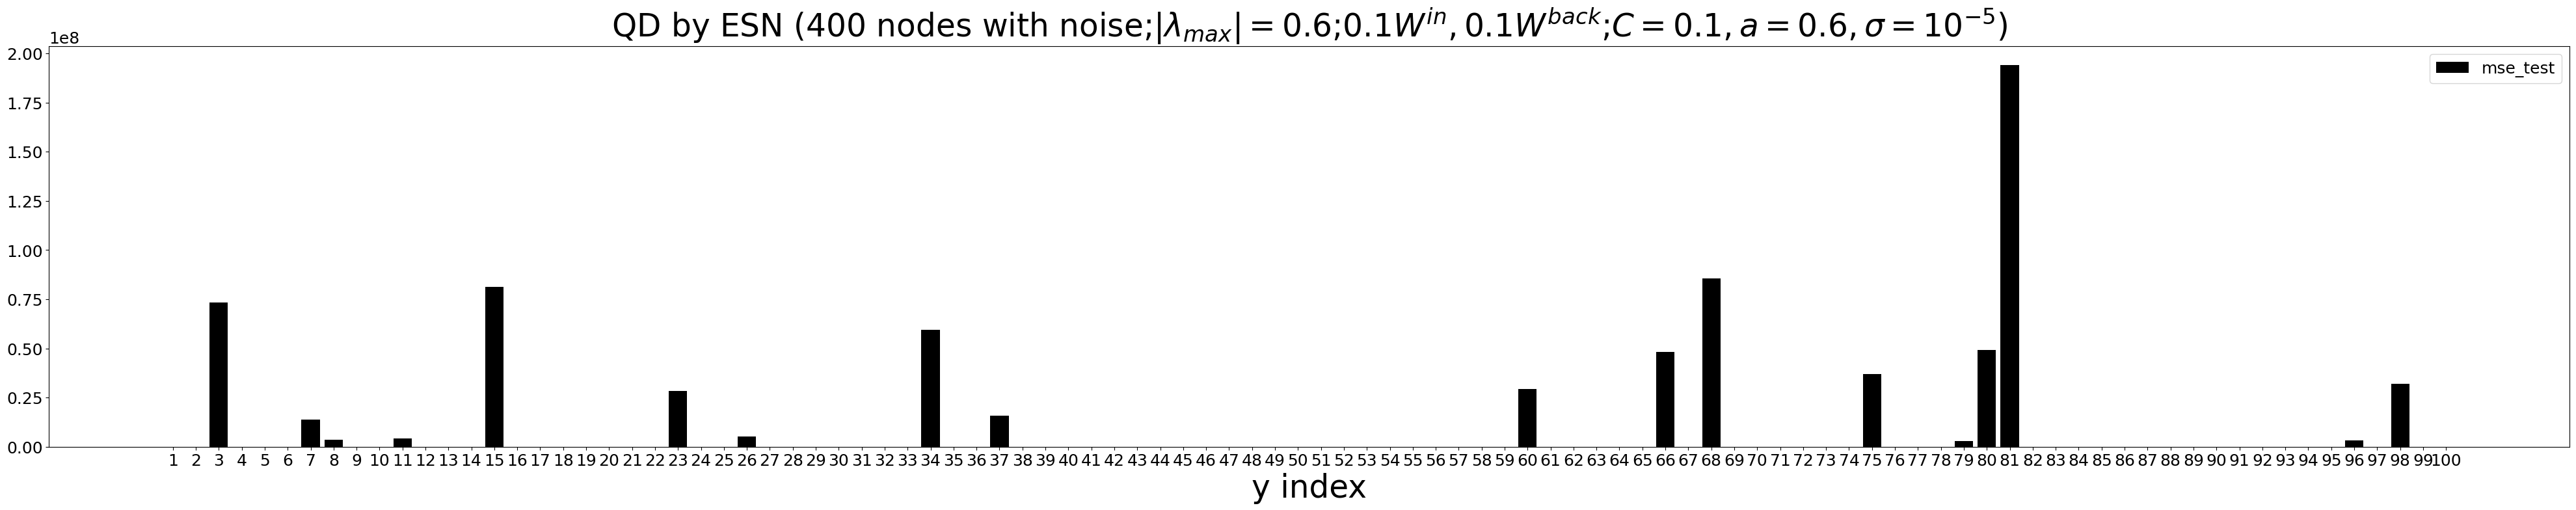

In [2]:
## Analysing a parameter setting
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':18})
T = [f'{i+1}' for i in range(100)]
#MSE_TRAIN = np.load('Quantum_dynamics/Adding_noise/Results_0/MSE_TRAIN.npy')
MSE_TEST = np.load(f'New/Results_4/MSE_TEST.npy')
plt.figure(figsize=(50,8))
#plt.bar(T,MSE_TRAIN,color='black',label='mse_train')
plt.bar(T,MSE_TEST,color='black',label='mse_test')
plt.xlabel('y index',fontsize=35)
#plt.ylabel('mse_test')
plt.title(r'QD by ESN (400 nodes with noise;$|\lambda_{max}|= 0.6$;$0.1W^{in},0.1W^{back}$;$C=0.1,a=0.6,\sigma=10^{-5}$)', fontsize=35)
#plt.ylim(0,2000)
plt.legend()  

In [3]:
print(f'minimum mse = {min(MSE_TEST)}',f'index = {np.argmin(MSE_TEST)+1}')
#print(MSE_TEST[24])

DICT = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 1:
        DICT[f'{i+1}'] = MSE_TEST[i]

DICT_1 = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 0.1:
        DICT_1[f'{i+1}'] = MSE_TEST[i]

DICT_2 = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 0.01:
        DICT_2[f'{i+1}'] = MSE_TEST[i]

print(f'number of values less than one = {len(DICT)}')
print(f'number of values less than 0.1 = {len(DICT_1)}')
print(f'number of values less than 0.01 = {len(DICT_2)}')
print(DICT_2)

minimum mse = 0.0012461658347106253 index = 39
number of values less than one = 81
number of values less than 0.1 = 59
number of values less than 0.01 = 8
{'17': np.float64(0.009084881539880834), '18': np.float64(0.0036929419104460496), '39': np.float64(0.0012461658347106253), '45': np.float64(0.00397808126118784), '52': np.float64(0.0027586917117441703), '62': np.float64(0.0074735238865892735), '88': np.float64(0.0027992614719281835), '100': np.float64(0.0028388667919082874)}


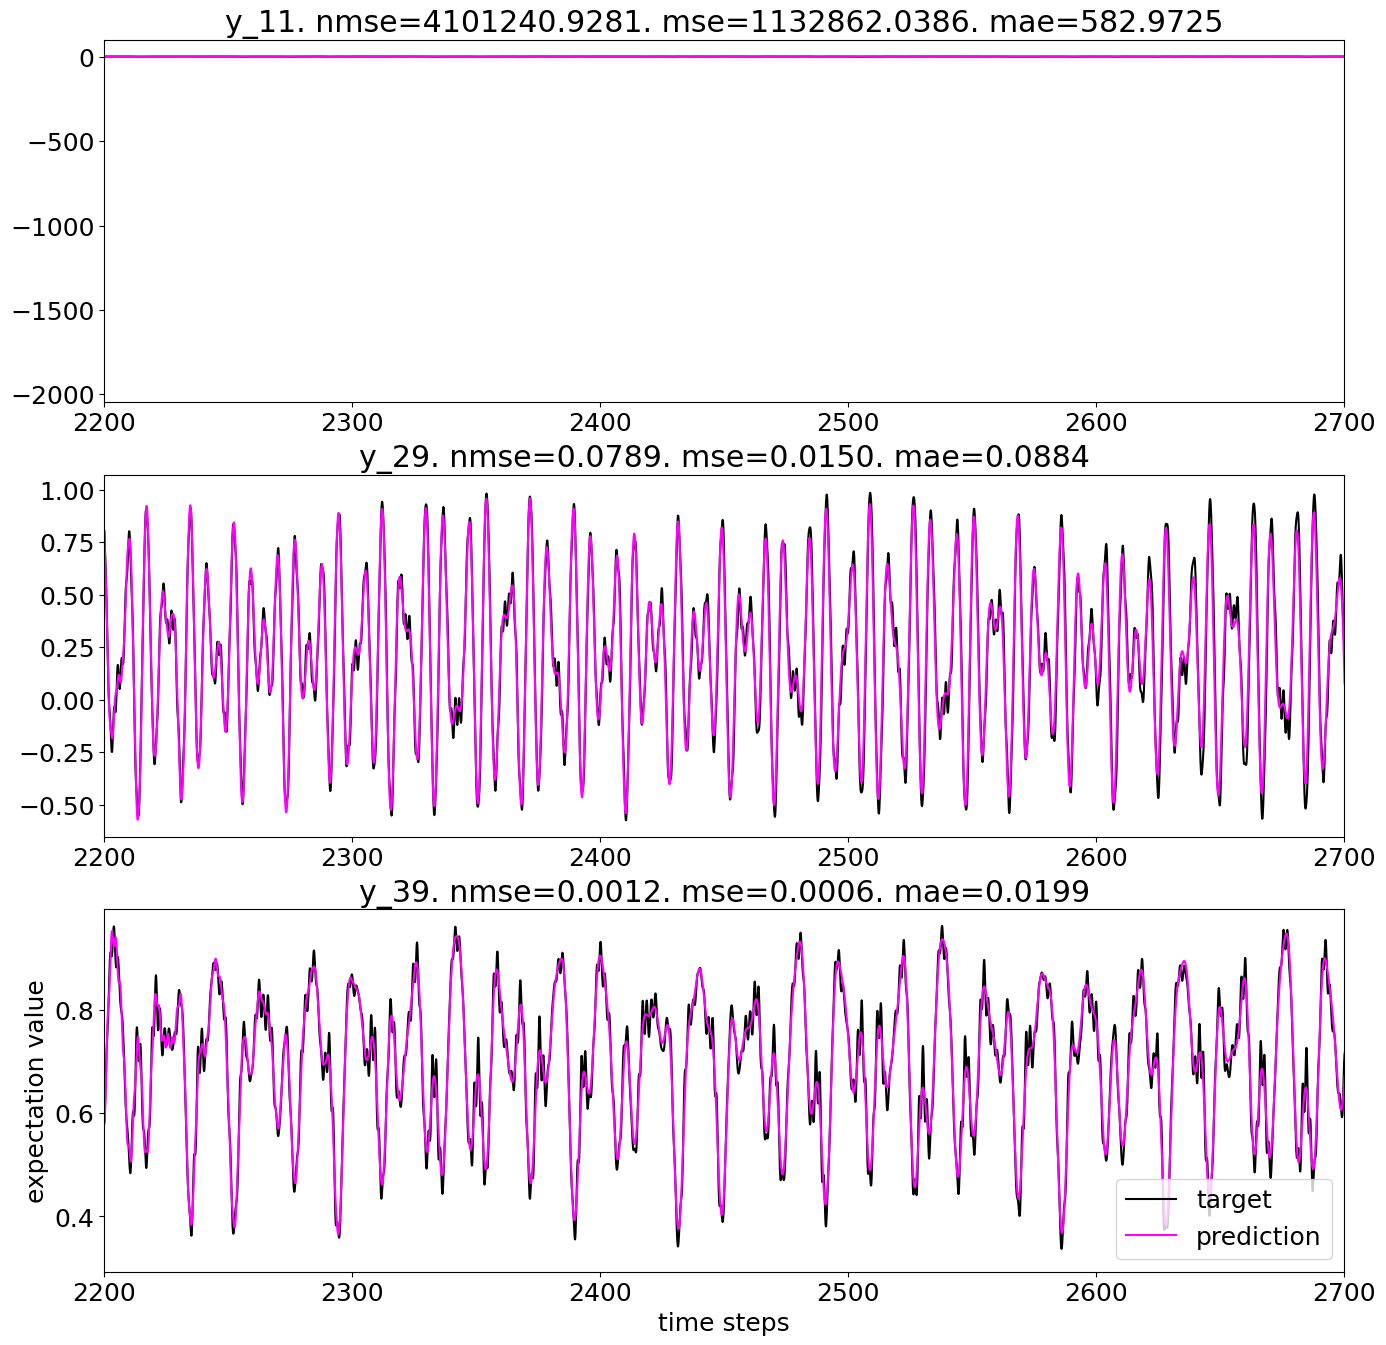

In [5]:
fig, axes = plt.subplots(3,1,figsize=(16,16))
washout = 2000
train = 20000
test= 10000
T = np.linspace(0,(washout+train+test-1)/10,washout+train+test)
index = [11,29,39]

for i in range(3):
    y_pred = np.load(f'New/Results_4/y_pred_{index[i]}.npy')
    y= np.load(f'New/Data_2/y_{index[i]}.npy')[:washout+train+test]
    nmse = np.sum((y[-test:]-y_pred)**2)/np.sum(y[-test:]**2)
    mse = np.mean((y[-test:]-y_pred)**2)
    mae = np.mean(abs(y[-test:]-y_pred))
    axes[i].plot(T[-test:],y[-test:],color='black',label='target')
    axes[i].plot(T[-test:],y_pred,color='magenta',label='prediction')
    axes[i].set_title(f'y_{index[i]}. nmse={nmse:.4f}. mse={mse:.4f}. mae={mae:.4f}')
    axes[i].set_xlim((washout+train)/10,(washout+train+test/2)/10)
    
axes[2].set_xlabel('time steps')
axes[2].set_ylabel('expectation value')
axes[2].legend()



Text(0, 0.5, '<Z> expectation value')

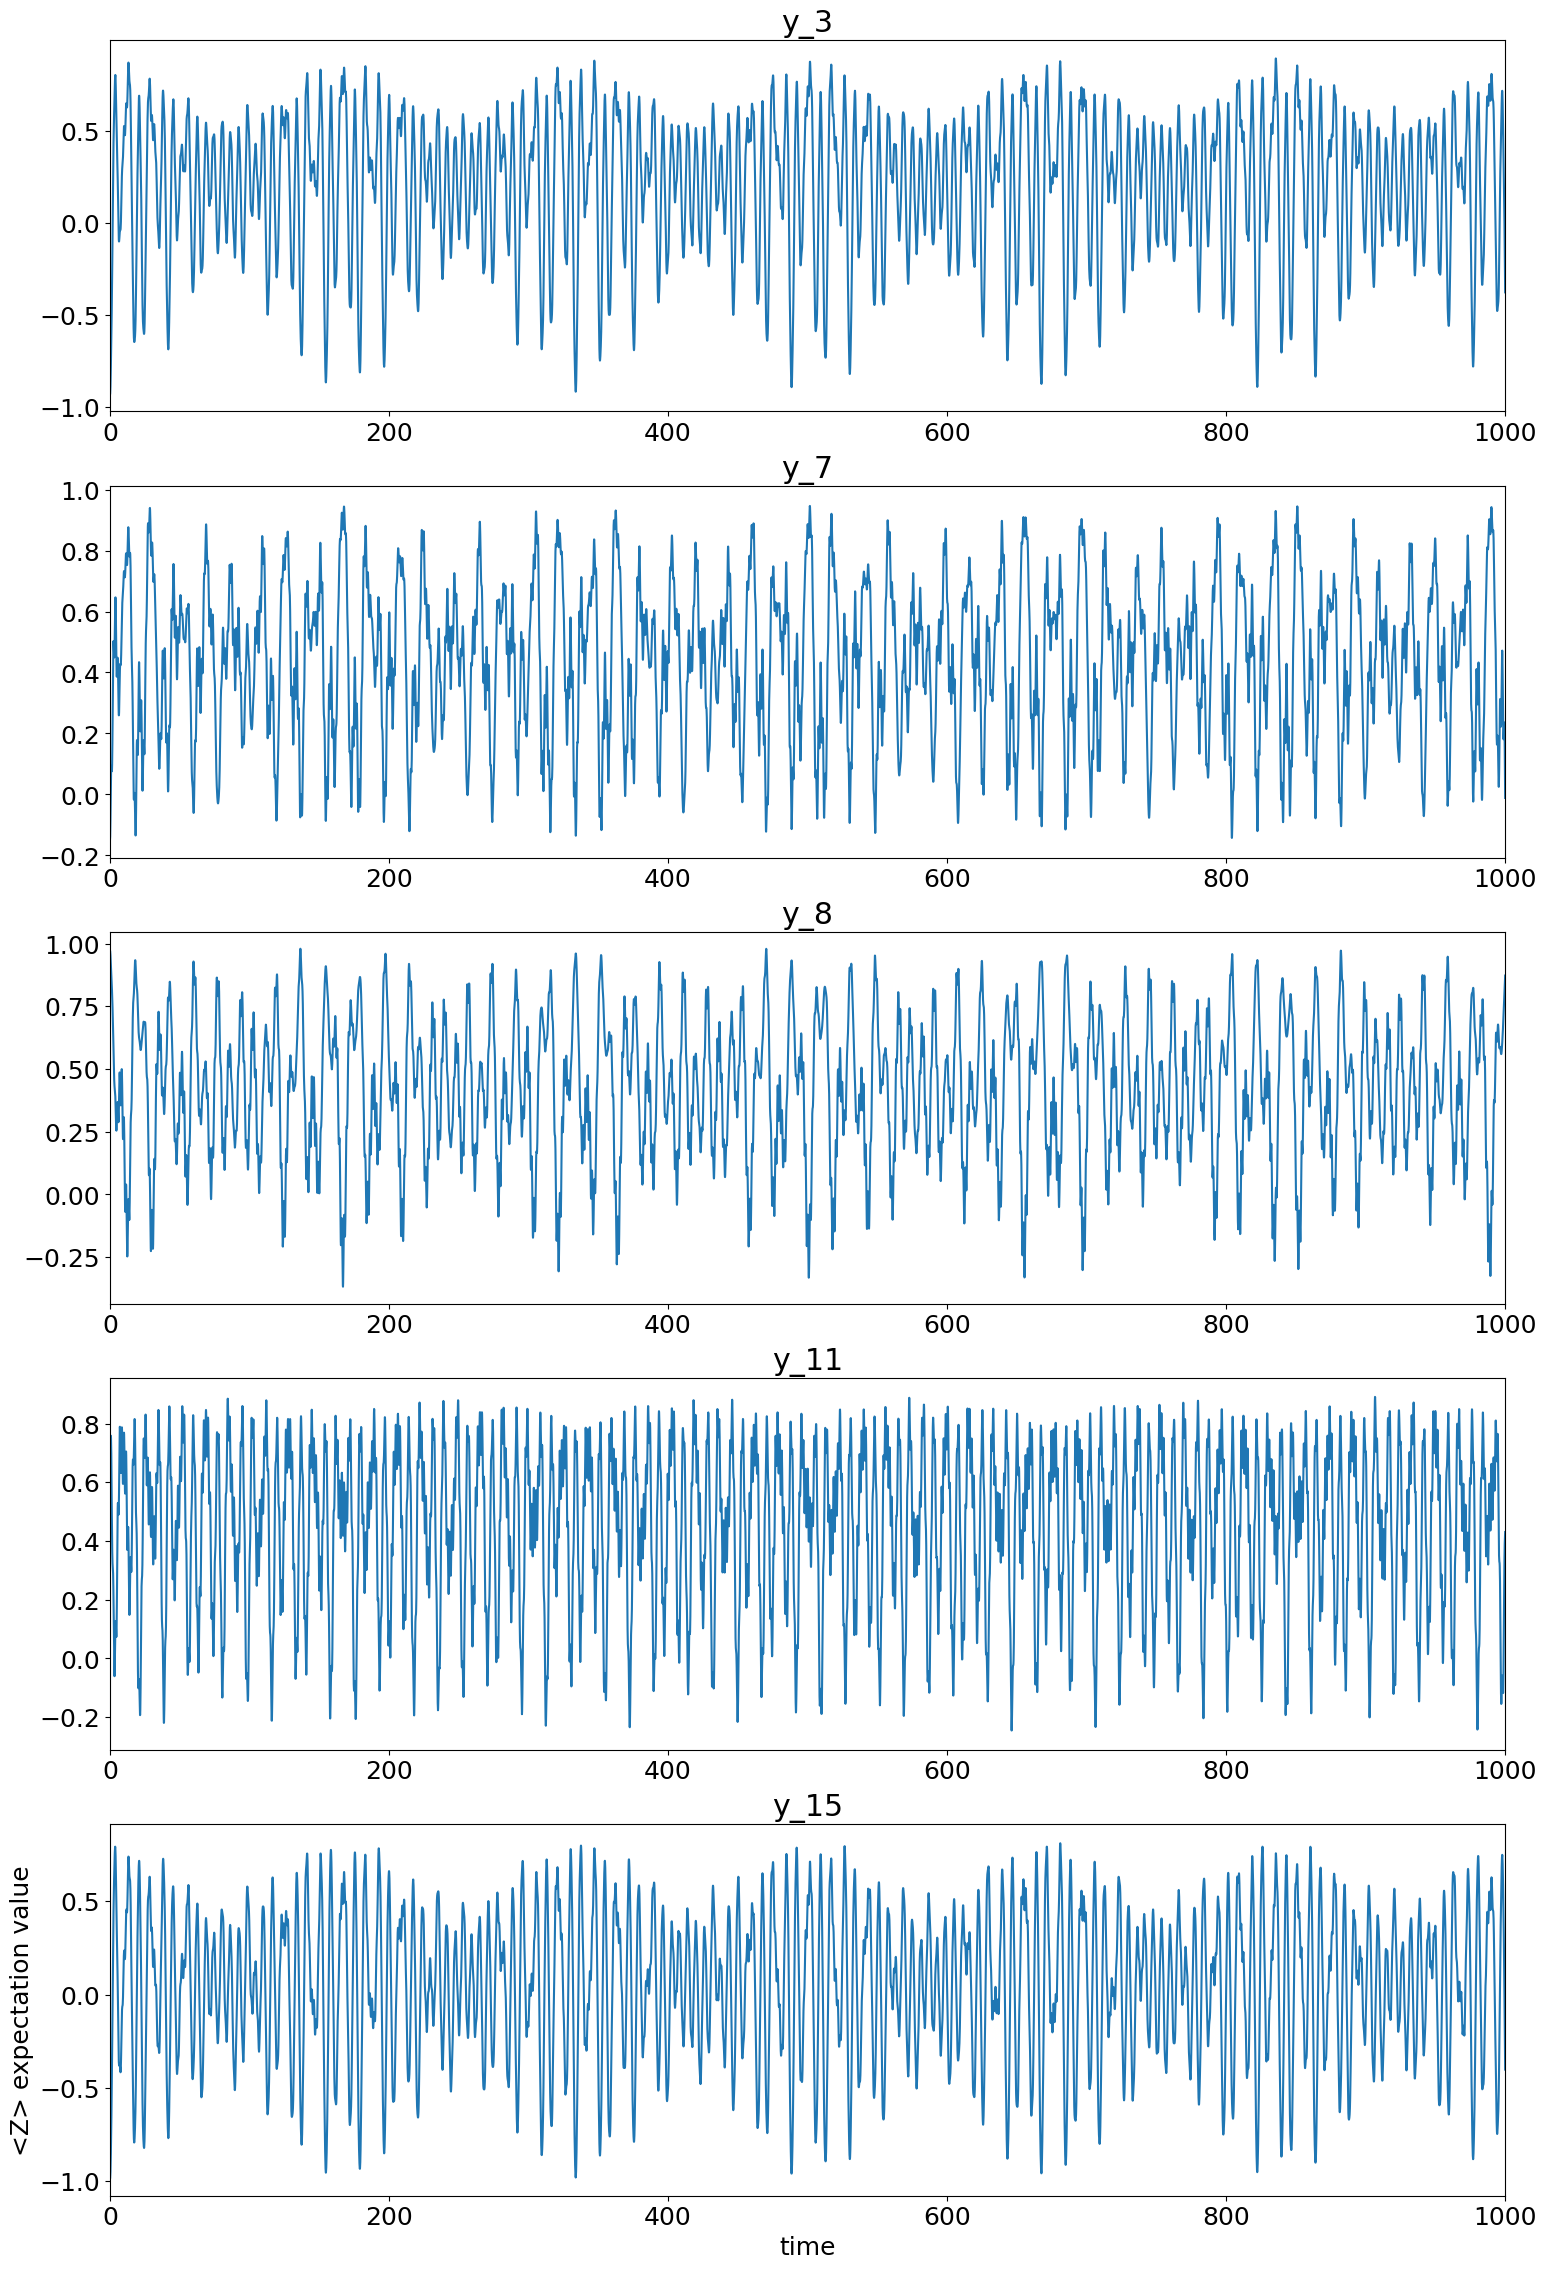

In [79]:
## Analysing the nature of a predictable series
fig, axes = plt.subplots(5,1,figsize=[18,26+2])

#indices = [17,18,39,45,52]  #good ones
indices = [3,7,8,11,15,23]  #bad ones
for i in range(5):
    y = np.load(f'New/Data_2/y_{indices[i]}.npy')[:washout+train+test]
    axes[i].plot(T,y)
    axes[i].set_title(f'y_{indices[i]}')
    axes[i].set_xlim(T[0],T[10000])
    #axes[i].set_xlim(0,50)

axes[4].set_xlabel('time')
axes[4].set_ylabel('<Z> expectation value')


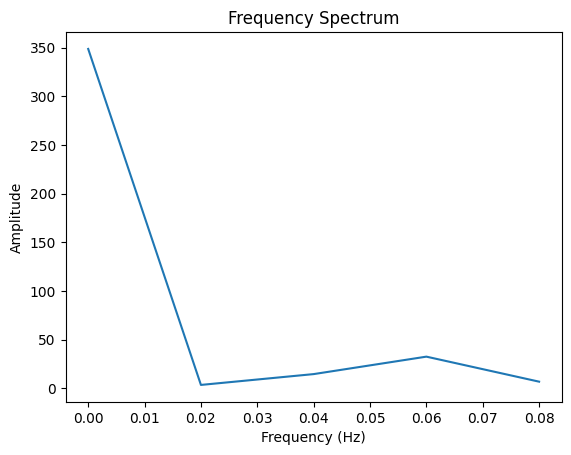

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a signal (e.g., a mix of 50Hz and 120Hz sine waves)
#fs = 500  # Sampling frequency
#t = np.arange(0, 1, 1/fs)
#signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 51 * t)
signal = np.load('New/Data_2/y_39.npy')[:500]
fs = 10

# 2. Compute the FFT
fft_values = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(signal), 1/fs)

# 3. Take the absolute value to get the magnitude (spectrum)
magnitude = np.abs(fft_values)

# Plotting
plt.plot(frequencies[:fs//2], magnitude[:fs//2]) # Plot positive frequencies
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
#plt.ylim(0,10)
#plt.xlim(0,0.0001)
plt.show()

In [ ]:
print(len)

[ 0.00000e+00  9.99990e-05  1.99998e-04 ... -2.99997e-04 -1.99998e-04
 -9.99990e-05]


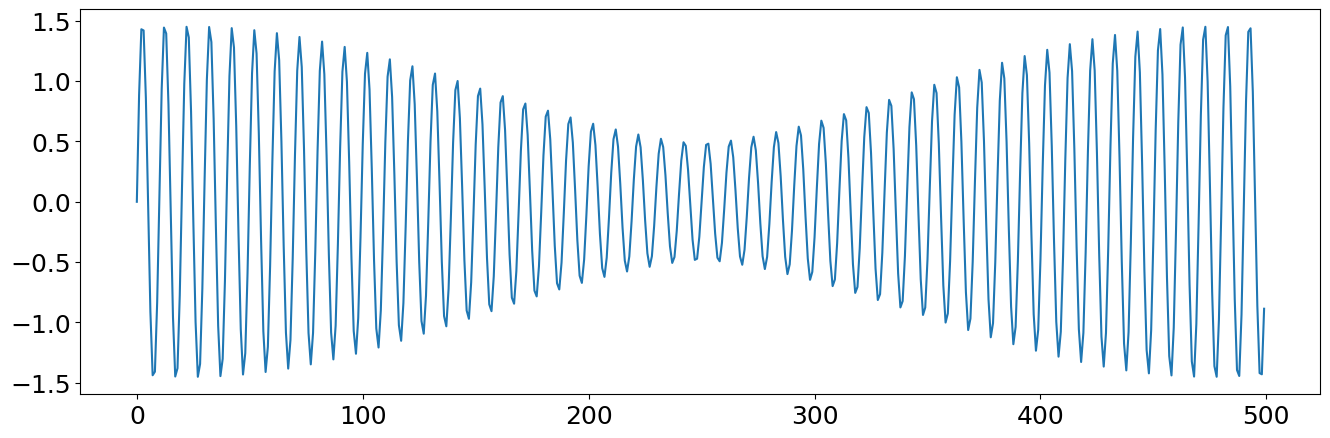

In [56]:
plt.figure(figsize=(16,5))
plt.plot(signal)

## SURFACE PLOTS OF n2

In [145]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS = np.load('New/ESN_PARAMETER_SEARCH_0.1.npy')


In [146]:
C = np.linspace(0.1,1,10)
X,Y=np.meshgrid(C,C)
Z = np.zeros([10,10])
for i in range(10):
    for j in range(10):
        Z[i,j] = RESULTS[10*i+j,-2]

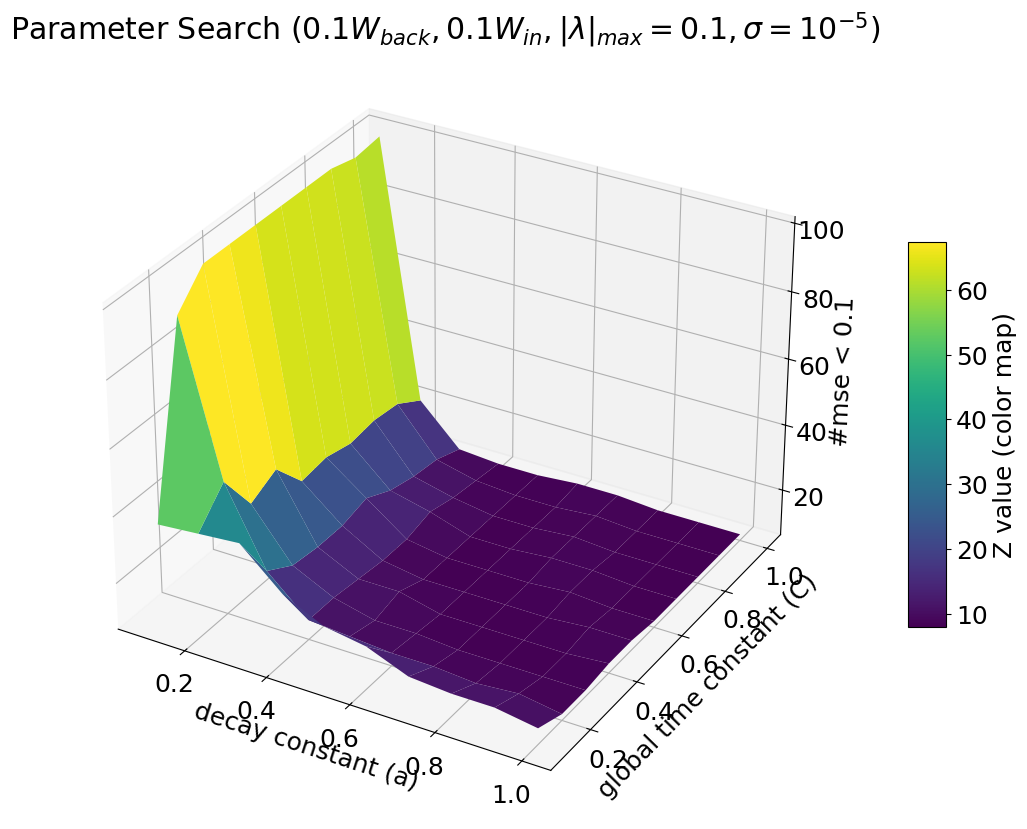

In [147]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111,projection='3d')

surf = ax.plot_surface(X,Y,Z,cmap='viridis',linewidth=0.1,antialiased=True)
ax.set_title(r'Parameter Search $(0.1W_{back},0.1W_{in},|\lambda|_{max}=0.1,\sigma=10^{-5})$')
ax.set_xlabel('decay constant (a)')
ax.set_ylabel('global time constant (C)')
ax.set_zlabel('#mse < 0.1')

plt.colorbar(surf,shrink=0.5,aspect=10,label='Z value (color map)')

#ax.text(0.8,0.1,90,'max height = 86',color='red',fontsize=10)
plt.show()

In [148]:
indices = np.where(RESULTS[:,-2]>99)
print(indices)
for i in indices:
    print(RESULTS[i,-2])

(array([ 20,  30,  40,  50,  60,  70, 111, 121, 141, 151, 202, 203, 212,
       213, 232, 303, 304, 314, 323, 404, 405, 414, 423, 505, 506, 507,
       515, 606, 607, 708, 716, 809, 816, 909]),)
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100.]


In [149]:
print(RESULTS[716,:])

[8.00000000e-01 2.00000000e-01 7.00000000e-01 1.00000000e+02
 1.00000000e+02 7.75576901e-05]


## Global rescaling

In [17]:
import numpy as np

DATA = np.load('New/ESN_PARAMETER_SEARCH_global_rescaling.npy')


In [18]:
print('Varying alpha_2')
print(['alpha_1*W_back','alpha_2*W_in', 'n1', 'n2', 'min_nmse'])
print(np.round(DATA,2))

Varying alpha_2
['alpha_1*W_back', 'alpha_2*W_in', 'n1', 'n2', 'min_nmse']
[[1.0e-01 5.0e-02 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 1.0e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 1.5e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 2.0e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 2.5e-01 1.0e+02 9.9e+01 0.0e+00]
 [1.0e-01 3.0e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 3.5e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 4.0e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 4.5e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 5.0e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 5.5e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 6.0e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 6.5e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 7.0e-01 1.0e+02 9.9e+01 0.0e+00]
 [1.0e-01 7.5e-01 1.0e+02 9.9e+01 0.0e+00]
 [1.0e-01 8.0e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 8.5e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 9.0e-01 1.0e+02 1.0e+02 0.0e+00]
 [1.0e-01 9.5e-01 1.0e+02 9.9e+01 0.0e+00]
 [1.0e-01 1.0e+00 1.0e+02 9.9e+01 0.0e+00]]


## FN_ED_MG

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("MG_Scan_over_h_val.npz")
print(data)

plt.figure(figsize=(10,5))
plt.semilogx(data["h_values"],data["success_count"])
plt.xlabel("h_values", fontsize=16)
plt.ylabel("success_count (out of 100)",fontsize=16)
plt.title(f"Mackey Glass Simulation (N,J,tau,V = {data["N"]},{data["J"]},{data["tau"]},{data["V"]})",fontsize=20,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
i = np.argmax(data["success_count"])
plt.scatter(data["h_values"][i],data["success_count"][i])
plt.text(data["h_values"][i]+0.2,data["success_count"][i],f"({data["h_values"][i]:.2f},{data["success_count"][i]})")


## Rough Work

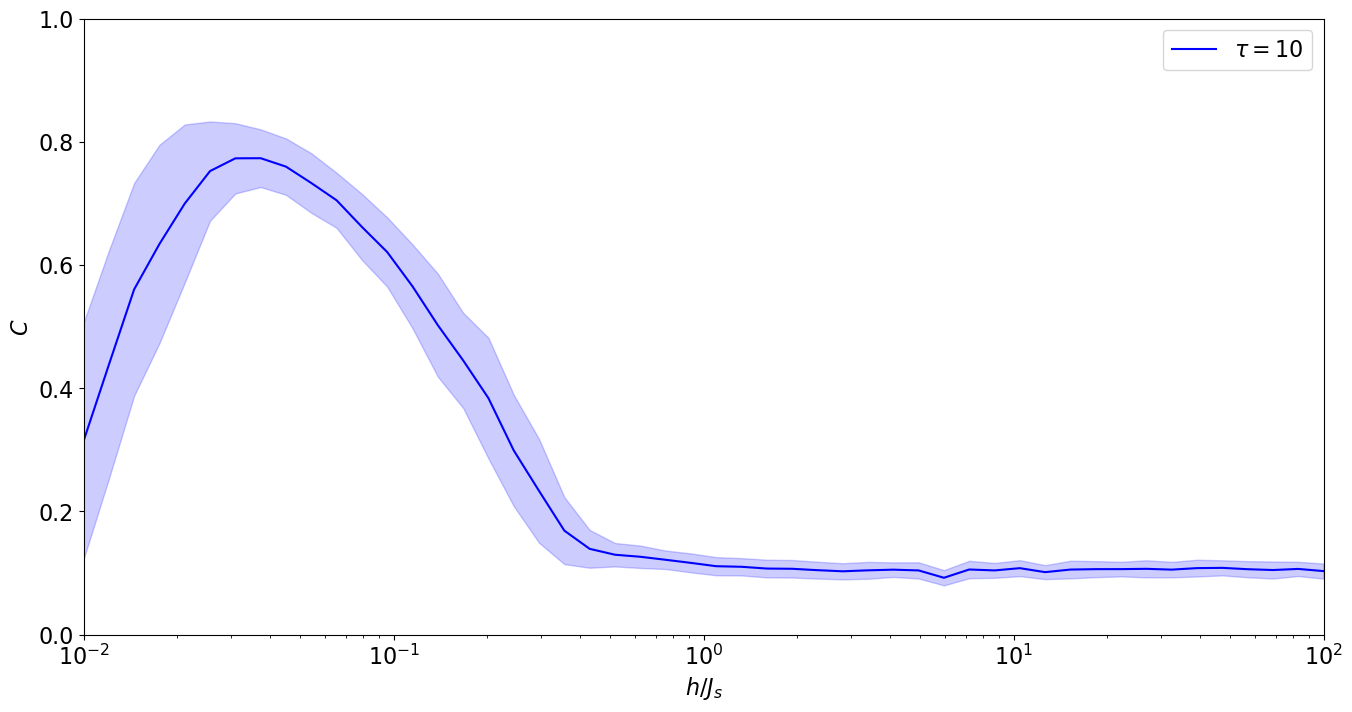

In [ ]:
# Plot of C vs h for Linear Memory and NARMA task using 10 spins RMP method.
import numpy as np
import matplotlib.pyplot as plt

# Load data
Data = np.load('Data/LinearMemory_Cvsh.npz')

# Extract variables for clarity
h = Data["h"]
c_mean = Data['c_mean']
c_std = Data['c_std'] # Assuming this exists; replace with your error key

# Calculate bounds
under_line = c_mean - c_std
over_line = c_mean + c_std

plt.figure(figsize=(16, 8))

# 1. Plot the mean line
plt.semilogx(h, c_mean, color='blue', label=r'$\tau =10$')

# 2. Add the error shadow
# alpha controls transparency (0 is invisible, 1 is solid)
plt.fill_between(h, under_line, over_line, color='blue', alpha=0.2)

plt.xlabel(r'$h/J_s$', fontsize=16)
plt.ylabel(r'$C$',fontsize=16)
#plt.title('Semilogx with Error Shadow')
plt.legend(fontsize=16)
#plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(10**-2,10**2)
plt.ylim(0.0,1.0)
plt.show()

In [18]:
print(Data['model'])

Transverse-Field Fully-Connected Ising Model


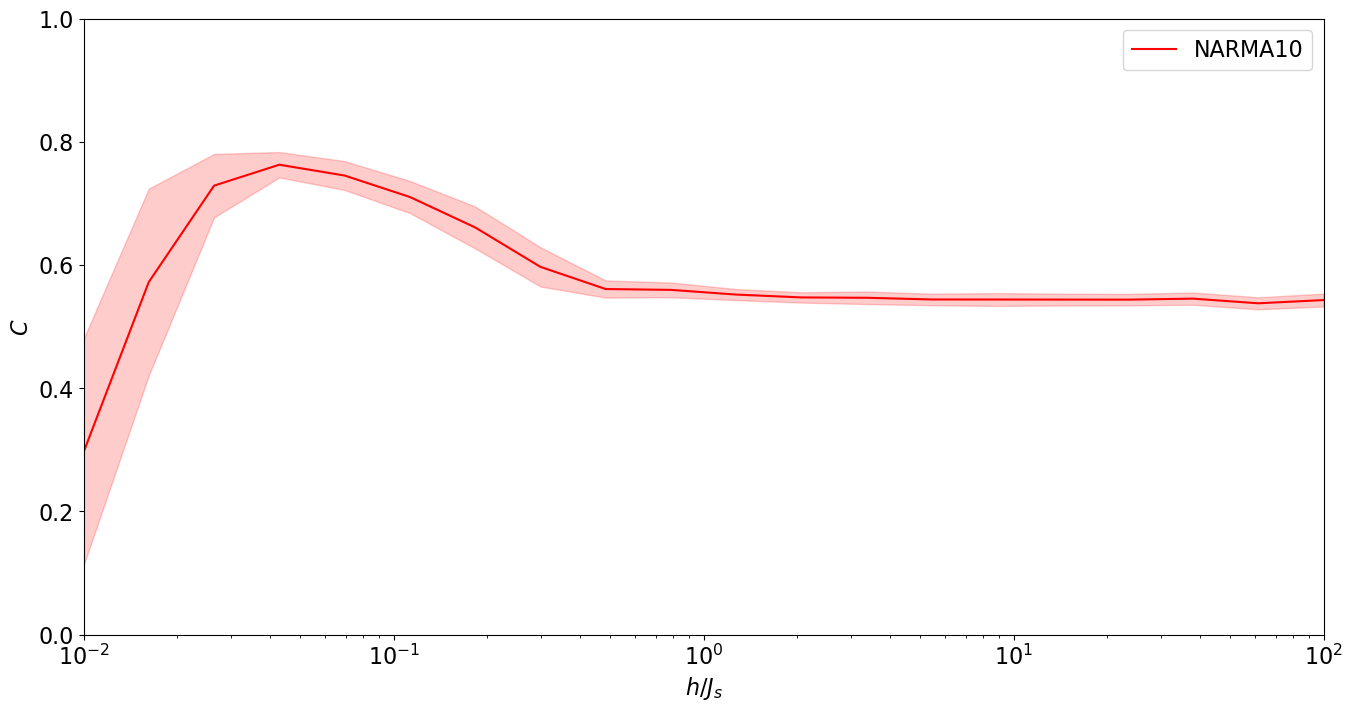

In [36]:
# Load data
Data = np.load('Data/RMP_NARMA_Cvh_groupHPC.npz')
# Extract variables for clarity
h = Data["h"]
c_mean = Data['c_mean']
c_std = Data['c_std'] # Assuming this exists; replace with your error key

# Calculate bounds
under_line = c_mean - c_std
over_line = c_mean + c_std

plt.figure(figsize=(16, 8))

# 1. Plot the mean line
plt.semilogx(h, c_mean, color='red', label=r'NARMA10')

# 2. Add the error shadow
# alpha controls transparency (0 is invisible, 1 is solid)
plt.fill_between(h, under_line, over_line, color='red', alpha=0.2)

plt.xlabel(r'$h/J_s$', fontsize=16)
plt.ylabel(r'$C$',fontsize=16)
#plt.title('Semilogx with Error Shadow')
plt.legend(fontsize=16)
#plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(10**-2,10**2)
plt.ylim(0.0,1.0)
plt.show()